# SFR Fly Mean-Reversion — 9. Data-chosen structures (arbitragelab)

Every framework so far took the butterfly as given: consecutive contracts,
weights `1/-2/1`. This one lets the data choose both.

* **Box-Tiao** — the linear combination of a fly's three legs with the lowest
  predictability, i.e. the fastest-reverting portfolio those legs can form.
* **Greedy sparse search** — the most mean-reverting 3-contract portfolio out
  of the *whole* strip, with unconstrained weights. It is free to pick
  non-adjacent contracts and unequal wings.
* **Bertram** and **Zeng** optimal thresholds, and Zeng's "reverse at the
  opposite band" rule, which halves trade length versus unwinding at the mean.
* **TAR** (Enders-Granger) — does the fly revert *faster when rich than when
  cheap*? A symmetric z-score rule cannot express that.
* **H-construction** — an inversion-counting mean-reversion statistic that is
  orthogonal to both half-life and Hurst.

`arbitragelab` is installed editable in this environment (mapped to
`RVUtils/arbitragelab`), so these are reference implementations, not
re-derivations. Two gotchas are handled explicitly below, both verified:
`OUModelOptimalThreshold*.fit_ou_model_to_data` takes `np.log(data)`
internally and therefore **fails silently to NaN on a bp series that goes
negative**, and `box_tiao` uses `np.linalg.eig` on a non-symmetric matrix,
which can return complex eigenpairs on near-collinear futures legs.

The vendored `mlfinlab` is deliberately **not** used: ~95% of its function
bodies are `pass`, so `get_sadf`, `frac_diff`, `trend_scanning_labels` and the
whole `bet_sizing` module import fine, run instantly, and return `None`. Where
something equivalent is needed, `arch.unitroot` (already installed) is used
instead.

In [1]:
CONFIG = dict(
    primary_structure="3m",
    primary_window="liquid16",
    cost_bp=1.5,
    n_packages=100,
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "half", "t10"),
    directions=("fade", "momentum"),
    z_window=120,
    max_hold=30,
    lag=1,
    greedy_cardinality=3,
    hurst_max_lags=20,      # the MC null below shows why 100 is unusable at n~1150
    mc_paths=300,
)
CONFIG

{'primary_structure': '3m',
 'primary_window': 'liquid16',
 'cost_bp': 1.5,
 'n_packages': 100,
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 'half', 't10'),
 'directions': ('fade', 'momentum'),
 'z_window': 120,
 'max_hold': 30,
 'lag': 1,
 'greedy_cardinality': 3,
 'hurst_max_lags': 20,
 'mc_paths': 300}

In [2]:
import sys
import warnings
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig
from RVUtils.MeanRev.signals import zscore_signal
from RVUtils.mean_reversion import adf_pvalue, calibrate_ou, half_life, hurst_exponent
from sfr_fly_meanrev_common import load_lab, run_family

pd.set_option("display.width", 235)
pd.set_option("display.max_columns", 60)

BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
lab = load_lab(CONFIG["primary_structure"], CONFIG["primary_window"])
levels, st, slot_panel = lab["levels"], lab["struct"], lab["slot_panel"]
print(f"{levels.shape[1]} flies, {levels.shape[0]} sessions; strip {slot_panel.shape}")

34 flies, 1150 sessions; strip (1150, 16)


## 1. What Hurst value actually means at this sample size

A Monte-Carlo null under a pure random walk of the same length. Without it,
"H = 0.44, therefore mean-reverting" is a coin flip dressed as a statistic.

In [3]:
n_bars = int(levels.notna().sum().median())
rng = np.random.default_rng(0)
rows = []
for ml in (20, 50, 100):
    vals = [hurst_exponent(pd.Series(np.cumsum(rng.standard_normal(n_bars))),
                           max_lag=ml, method="std")
            for _ in range(CONFIG["mc_paths"])]
    v = np.asarray(vals, float)
    rows.append({"max_lag": ml, "n_bars": n_bars, "mean": v.mean(), "sd": v.std(),
                 "p05": np.percentile(v, 5), "p95": np.percentile(v, 95)})
null = pd.DataFrame(rows)
print(f"random-walk null for the Hurst exponent, {CONFIG['mc_paths']} paths of "
      f"{n_bars} bars:")
print(null.round(4).to_string(index=False))
H_CRIT = float(null.loc[null["max_lag"] == CONFIG["hurst_max_lags"], "p05"].iloc[0])
print(f"\n  one-sided 5% critical value at max_lag={CONFIG['hurst_max_lags']}: "
      f"H < {H_CRIT:.3f}")
print("  a wider max_lag has a FATTER null, so it is the worse choice despite "
      "using more of the series.")

random-walk null for the Hurst exponent, 300 paths of 481 bars:
 max_lag  n_bars   mean     sd    p05    p95
      20     481 0.4827 0.0539 0.3907 0.5611
      50     481 0.4689 0.0696 0.3483 0.5738
     100     481 0.4261 0.0931 0.2753 0.5731

  one-sided 5% critical value at max_lag=20: H < 0.391
  a wider max_lag has a FATTER null, so it is the worse choice despite using more of the series.


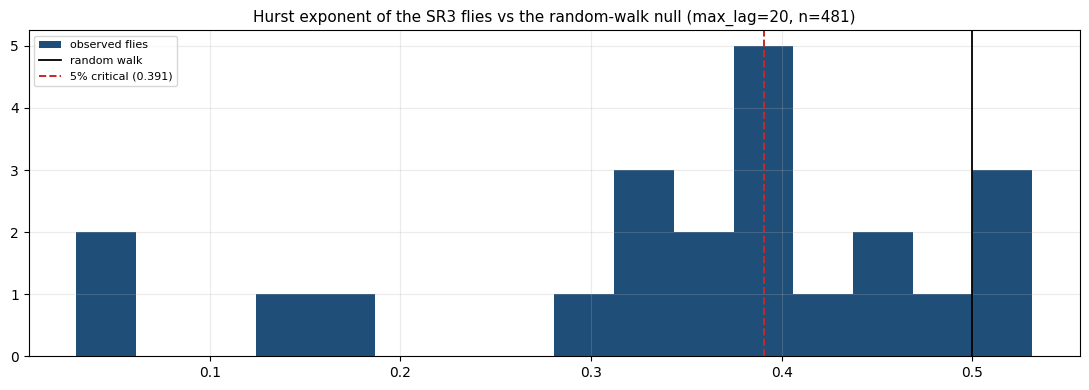

flies significantly mean-reverting at 5%: 15/22


In [4]:
obs = pd.Series({c: hurst_exponent(levels[c].dropna(),
                                   max_lag=CONFIG["hurst_max_lags"], method="std")
                 for c in levels.columns if levels[c].notna().sum() > 300})
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(obs.dropna(), bins=16, color="#1f4e79", label="observed flies")
ax.axvline(0.5, color="black", lw=1.3, label="random walk")
ax.axvline(H_CRIT, color="#c62828", lw=1.4, ls="--",
           label=f"5% critical ({H_CRIT:.3f})")
ax.set_title(f"Hurst exponent of the SR3 flies vs the random-walk null "
             f"(max_lag={CONFIG['hurst_max_lags']}, n={n_bars})", fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
print(f"flies significantly mean-reverting at 5%: "
      f"{int((obs < H_CRIT).sum())}/{int(obs.notna().sum())}")

## 2. Box-Tiao — is `1/-2/1` the most mean-reverting weighting of these legs?

In [5]:
try:
    from arbitragelab.cointegration_approach.sparse_mr_portfolio import (
        SparseMeanReversionPortfolio,
    )
    HAVE_AL = True
except Exception as exc:
    print(f"arbitragelab unavailable: {type(exc).__name__}: {exc}")
    HAVE_AL = False

bt_rows = []
if HAVE_AL:
    for key, g in st.groupby("key"):
        g = g.sort_values("as_of")
        if len(g) < 400:
            continue
        idx = pd.DatetimeIndex(g["as_of"])
        legs = pd.DataFrame({"front": g["leg0_value"].to_numpy(float),
                             "belly": g["leg1_value"].to_numpy(float),
                             "back": g["leg2_value"].to_numpy(float)}, index=idx)
        try:
            sp = SparseMeanReversionPortfolio(legs)
            M = sp.box_tiao()
            if np.iscomplexobj(M):
                continue                     # near-collinear legs; eig went complex
            w = M[:, -1]                     # last column = least predictable
            if abs(w[1]) < 1e-9:
                continue
            w = w / w[1] * 2.0               # normalise belly to +2, the fly convention
            mu_bt, hl_bt = sp.mean_rev_coeff(M[:, -1], legs, interval="D")
            fly_w = np.array([-1.0, 2.0, -1.0])
            mu_fl, hl_fl = sp.mean_rev_coeff(fly_w / np.linalg.norm(fly_w), legs,
                                             interval="D")
        except Exception:
            continue
        bt_rows.append({"key": key, "w_front": w[0], "w_belly": w[1], "w_back": w[2],
                        "hl_boxtiao_d": hl_bt, "hl_fly_d": hl_fl,
                        "mu_boxtiao": mu_bt, "mu_fly": mu_fl})
bt = pd.DataFrame(bt_rows)
if not bt.empty:
    print(bt.round(4).to_string(index=False))
    print("\nthe butterfly asserts w_front = w_back = -1 with belly +2:")
    print(bt[["w_front", "w_back", "hl_boxtiao_d", "hl_fly_d"]].describe()
          .round(4).to_string())
    print(f"\n  median |w_front - (-1)| = {(bt['w_front'] + 1).abs().median():.4f}")
    print(f"  median |w_back  - (-1)| = {(bt['w_back'] + 1).abs().median():.4f}")
    print(f"  half-life: Box-Tiao {bt['hl_boxtiao_d'].median():.3f}d vs "
          f"asserted fly {bt['hl_fly_d'].median():.3f}d")
else:
    print("no Box-Tiao rows produced")

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

        key  w_front  w_belly  w_back  hl_boxtiao_d     hl_fly_d  mu_boxtiao   mu_fly
H24-M24-U24  -0.7406      2.0 -1.3574  1.781350e+01 4.202390e+01      9.8056   4.1565
H25-M25-U25  -0.6153      2.0 -1.4406  2.575250e+01 4.304250e+01      6.7828   4.0582
H26-M26-U26  -0.8623      2.0 -1.1374  2.812210e+01 1.746731e+07      6.2112   0.0000
H27-M27-U27  -1.1654      2.0 -0.8580  1.070200e+01 2.305200e+01     16.3216   7.5774
H28-M28-U28  -0.8563      2.0 -1.1533  1.317100e+00 1.309000e+00    132.6153 133.4361
M24-U24-Z24  -0.6107      2.0 -1.5070  1.720950e+01 9.827280e+01     10.1498   1.7774
M25-U25-Z25  -1.2240      2.0 -0.6929  2.506270e+01 1.315000e+00      6.9695 132.8262
M26-U26-Z26  -0.6865      2.0 -1.3048  2.042580e+01 5.744670e+01      8.5516   3.0406
M27-U27-Z27  -0.9807      2.0 -1.0398  5.866200e+00 7.998700e+00     29.7761  21.8376
M28-U28-Z28  -0.9386      2.0 -1.0638  1.320300e+00 1.320100e+00    132.2967 132.3213
U23-Z23-H24  -0.9916      2.0 -1.0765  2.207680e+01 5.

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## 3. Greedy sparse search — which three contracts, and what weights?

Unconstrained over the whole 16-contract strip. If the answer keeps coming back
adjacent-and-equal-winged, the butterfly convention is vindicated by the data.
If it does not, the lab has been testing the wrong structure all along.

In [6]:
greedy = None
if HAVE_AL:
    strip = slot_panel.dropna(axis=1, how="all").dropna()
    strip.columns = [f"S{int(c)}" for c in strip.columns]
    try:
        sp_all = SparseMeanReversionPortfolio(strip)
        var_est = sp_all.least_square_VAR_fit(use_standardized=False)
        cov_est = sp_all.demeaned.cov().values
        rows = []
        for card in (3, 4):
            w = SparseMeanReversionPortfolio.greedy_search(
                card, var_est, cov_est, maximize=False).ravel()
            sel = np.flatnonzero(np.abs(w) > 1e-6)
            mu_g, hl_g = sp_all.mean_rev_coeff(w, strip, interval="D")
            rows.append({"cardinality": card,
                         "legs": [strip.columns[i] for i in sel],
                         "weights": np.round(w[sel], 4).tolist(),
                         "mu_per_yr": mu_g, "half_life_d": hl_g})
        greedy = pd.DataFrame(rows)
        print(greedy.to_string(index=False))
    except Exception as exc:
        print(f"greedy_search failed: {type(exc).__name__}: {exc}")

 cardinality              legs                            weights  mu_per_yr  half_life_d
           3     [S1, S2, S16]          [0.4159, -0.6667, 0.6185]   1.642111   106.371035
           4 [S1, S2, S7, S16] [-0.3966, 0.5366, -0.5849, 0.4612]   7.045334    24.792735


C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [7]:
# The greedy 3-leg portfolio as a tradeable level series, backtested like a fly.
greedy_lv = None
if greedy is not None and HAVE_AL:
    row = greedy[greedy["cardinality"] == 3].iloc[0]
    legs_sel, w_sel = row["legs"], np.array(row["weights"], dtype=float)
    # normalise so the largest-magnitude weight is 2 -> comparable package size
    w_norm = w_sel / np.abs(w_sel).max() * 2.0
    ser = sum(w * strip[c] for w, c in zip(w_norm, legs_sel)) * 100.0
    greedy_lv = pd.DataFrame({"greedy3": ser}).reindex(levels.index).dropna()
    print(f"greedy portfolio: {dict(zip(legs_sel, np.round(w_norm, 3)))}")
    print(f"  level bp: mean {ser.mean():.2f}, sd {ser.std():.2f}, "
          f"half-life {half_life(ser):.2f}d, ADF p {adf_pvalue(ser):.4f}")
    print("  NOTE: these are CONSTANT-MATURITY slots, so this series rolls. It "
          "is a diagnostic of what the data prefers, not a tradeable backtest.")

greedy portfolio: {'S1': np.float64(1.248), 'S2': np.float64(-2.0), 'S16': np.float64(1.855)}
  level bp: mean 328.29, sd 100.21, half-life 106.37d, ADF p 0.3792
  NOTE: these are CONSTANT-MATURITY slots, so this series rolls. It is a diagnostic of what the data prefers, not a tradeable backtest.


## 4. Bertram and Zeng optimal thresholds

Both classes' `fit_ou_model_to_data` log-transform internally, which silently
produces `theta = NaN, mu = 100, sigma = 100` on a bp series that crosses zero.
The OU is therefore fitted here on the raw series and injected.

In [8]:
def fit_ou_annualised(series, dt=1 / 252):
    """(theta, mu_per_year, sigma_per_sqrt_year) on a RAW level series."""
    x = np.asarray(pd.Series(series).dropna(), float)
    if x.size < 50:
        return None
    x0, x1 = x[:-1], x[1:]
    b, a = np.polyfit(x0, x1, 1)
    if not (0 < b < 1):
        return None
    mu = -np.log(b) / dt
    theta = a / (1 - b)
    resid = x1 - (a + b * x0)
    sigma = resid.std(ddof=2) * np.sqrt(2 * mu / (1 - b ** 2))
    return float(theta), float(mu), float(sigma)


thr_rows = []
if HAVE_AL:
    try:
        from arbitragelab.time_series_approach.ou_optimal_threshold_bertram import (
            OUModelOptimalThresholdBertram,
        )
        from arbitragelab.time_series_approach.ou_optimal_threshold_zeng import (
            OUModelOptimalThresholdZeng,
        )
        cm = lab["cm_levels"]
        for c in cm.columns:
            p = fit_ou_annualised(cm[c])
            if p is None:
                continue
            theta, mu, sigma = p
            rec = {"cm": c, "slot": lab["slot_of_label"][c], "theta_bp": theta,
                   "mu_per_yr": mu, "hl_d": np.log(2) / mu * 252}
            try:
                b = OUModelOptimalThresholdBertram()
                b.construct_ou_model_from_given_parameters(theta=theta, mu=mu,
                                                           sigma=sigma)
                a_e, m_x = b.get_threshold_by_maximize_expected_return(
                    c=CONFIG["cost_bp"])
                rec.update({"bert_entry_bp": a_e, "bert_exit_bp": m_x,
                            "bert_len_d": b.expected_trade_length(a_e, m_x) * 252,
                            "bert_ret_bp_yr": b.expected_return(a_e, m_x,
                                                                CONFIG["cost_bp"]),
                            "bert_sr": b.sharpe_ratio(a_e, m_x, CONFIG["cost_bp"], 0.0)})
            except Exception:
                pass
            try:
                z = OUModelOptimalThresholdZeng()
                z.construct_ou_model_from_given_parameters(theta=theta, mu=mu,
                                                           sigma=sigma)
                a_s, b_s, a_l, b_l = z.get_threshold_by_new_optimal_rule(
                    c=CONFIG["cost_bp"])
                rec.update({"zeng_short_in": a_s, "zeng_short_out": b_s,
                            "zeng_long_in": a_l, "zeng_long_out": b_l,
                            "zeng_len_d": z.expected_trade_length(a_s, b_s) * 252,
                            "zeng_ret_bp_yr": z.expected_return(a_s, b_s,
                                                                CONFIG["cost_bp"])})
            except Exception:
                pass
            thr_rows.append(rec)
    except Exception as exc:
        print(f"threshold models unavailable: {type(exc).__name__}: {exc}")
thr = pd.DataFrame(thr_rows).sort_values("slot") if thr_rows else pd.DataFrame()
if not thr.empty:
    print(thr.round(3).to_string(index=False))
    print("\n  bert_ret_bp_yr is expected bp PER YEAR per package at the optimal "
          "band, already net of the 1.5bp round trip.")

          cm  slot  theta_bp  mu_per_yr   hl_d  bert_entry_bp  bert_exit_bp  bert_len_d  bert_ret_bp_yr  bert_sr  zeng_short_in  zeng_short_out  zeng_long_in  zeng_long_out  zeng_len_d  zeng_ret_bp_yr
      SFR123     2     8.882      5.213 33.504          7.372        10.392      23.334          16.416    1.935         10.392           7.372         7.372         10.392      11.665          32.836
      SFR234     3     2.698      3.315 52.699          1.188         4.208      54.150           7.074    1.539          4.208           1.188         1.188          4.208      27.071          14.150
      SFR345     4     0.346      4.139 42.199         -1.164         1.856      54.470           7.032    1.715          1.856          -1.164        -1.164          1.856      27.231          14.067
      SFR456     5    -1.816      4.493 38.879         -3.328        -0.304      66.636           5.767    1.777         -0.304          -3.328        -3.328         -0.304      33.313          11

## 5. TAR — is the adjustment asymmetric?

Enders-Granger threshold autoregression. `p_1` is the reversion speed above the
threshold, `p_2` below. If the F-test rejects, a rich fly and a cheap fly do not
revert at the same speed, and a symmetric z-score rule is leaving that on the
table.

In [9]:
tar_rows = []
if HAVE_AL:
    try:
        from arbitragelab.ml_approach.tar import TAR
        for c in lab["cm_levels"].columns:
            s = lab["cm_levels"][c].dropna()
            if len(s) < 300:
                continue
            try:
                t = TAR(s)
                t.fit()
                sm = t.summary()
                tar_rows.append({"cm": c, "slot": lab["slot_of_label"][c],
                                 "p_1": sm.loc["Coefficient", "p_1"],
                                 "p_2": sm.loc["Coefficient", "p_2"],
                                 "p_1_pval": sm.loc["p-value", "p_1"],
                                 "p_2_pval": sm.loc["p-value", "p_2"],
                                 "sym_F": sm.loc["F-stat", "p_1 = p_2"],
                                 "sym_pval": sm.loc["p-value", "p_1 = p_2"]})
            except Exception:
                continue
    except Exception as exc:
        print(f"TAR unavailable: {type(exc).__name__}: {exc}")
tar = pd.DataFrame(tar_rows).sort_values("slot") if tar_rows else pd.DataFrame()
if not tar.empty:
    print(tar.round(4).to_string(index=False))
    print(f"\n  asymmetric adjustment rejected at 5% on "
          f"{int((tar['sym_pval'] < 0.05).sum())}/{len(tar)} slots")

          cm  slot     p_1     p_2  p_1_pval  p_2_pval   sym_F  sym_pval
      SFR123     2 -0.0132 -0.0431    0.0152    0.0193  2.4350    0.1189
      SFR234     3 -0.0118 -0.0137    0.0367    0.1027  0.0353    0.8510
      SFR345     4 -0.0162 -0.0164    0.0168    0.0589  0.0005    0.9830
      SFR456     5 -0.0173 -0.0157    0.0317    0.0269  0.0228    0.8799
      SFR567     6 -0.0206 -0.0101    0.0865    0.0367  0.6580    0.4174
      SFR678     7 -0.0521 -0.0049    0.0099    0.1256  5.3336    0.0211
      SFR789     8 -0.0321 -0.0101    0.0725    0.0246  1.4350    0.2312
  SFR-8-9-10     9 -0.2212 -0.0272    0.0001    0.0002 10.9838    0.0009
 SFR-9-10-11    10 -0.3158 -0.0434    0.0000    0.0000 38.9817    0.0000
SFR-10-11-12    11 -0.1591 -0.0713    0.0000    0.0000  9.3145    0.0023
SFR-11-12-13    12 -0.1337 -0.0791    0.0000    0.0000  4.1196    0.0426
SFR-12-13-14    13 -0.4790 -0.0762    0.0000    0.0000 38.4043    0.0000
SFR-13-14-15    14 -0.3302 -0.1117    0.0000    0.0

## 6. H-construction volatility — an orthogonal reversion statistic

Counts directional inversions rather than fitting an AR, so it does not assume
a functional form.

In [10]:
h_rows = []
if HAVE_AL:
    try:
        from arbitragelab.time_series_approach.h_strategy import HConstruction
        for c in lab["cm_levels"].columns:
            s = lab["cm_levels"][c].dropna()
            if len(s) < 300:
                continue
            thr_v = float(s.diff().std() * 2)
            if not np.isfinite(thr_v) or thr_v <= 0:
                continue
            try:
                hc = HConstruction(series=s, threshold=thr_v, method="Kagi")
                h_rows.append({"cm": c, "slot": lab["slot_of_label"][c],
                               "threshold_bp": thr_v, "h_inversion": hc.h_inversion(),
                               "h_vol_1": hc.h_volatility(p=1),
                               "h_vol_2": hc.h_volatility(p=2),
                               "half_life_d": half_life(s)})
            except Exception:
                continue
    except Exception as exc:
        print(f"HConstruction unavailable: {type(exc).__name__}: {exc}")
hh = pd.DataFrame(h_rows).sort_values("slot") if h_rows else pd.DataFrame()
if not hh.empty:
    print(hh.round(4).to_string(index=False))
    print("\n  h_volatility is the average absolute move per inversion, in bp. "
          f"Compare it with the {CONFIG['cost_bp']}bp round trip directly: a slot "
          "whose h_volatility is below the round trip cannot pay for its own "
          "inversions.")
    hh["pays_cost"] = hh["h_vol_1"] > CONFIG["cost_bp"]
    print(hh[["cm", "h_vol_1", "pays_cost"]].to_string(index=False))

          cm  slot  threshold_bp  h_inversion  h_vol_1  h_vol_2  half_life_d
      SFR123     2        6.3538           61  16.0656 351.0902      33.5044
      SFR234     3        3.4463           73   9.2260 128.1336      52.6990
      SFR345     4        3.0691           61   8.8443 121.7418      42.1985
      SFR456     5        2.4209           73   6.3425  53.5000      38.8791
      SFR567     6        1.9546           80   4.9000  32.7875      37.6151
      SFR678     7        1.2756           84   3.0238  12.2500      47.2420
      SFR789     8        1.3270           62   3.4516  17.9194      28.4974
  SFR-8-9-10     9        1.2117           69   2.6739   9.3007      11.6541
 SFR-9-10-11    10        0.9158          119   1.4160   2.8130       8.5555
SFR-10-11-12    11        1.1115           44   2.3977   8.5739       6.1150
SFR-11-12-13    12        0.9811          138   1.3623   2.5145       5.9440
SFR-12-13-14    13        0.8578          136   1.1691   1.4743       3.9646

## 7. Backtest — Box-Tiao weights as the signal, fly as the instrument

The Box-Tiao spread is not directly tradeable (non-integer weights), so as
elsewhere it supplies the signal while the executed package stays the
butterfly.


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/54 configs


  50/54 configs


  54 configs | median -392.88bp | IQR [-592.88, -258.00] | 0% net-positive | best -49.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 z_window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
      250      2.5         z0      fade       106     0.245      -0.467        -49.50      -123750.0  -0.572     -69.25
      250      2.5       half      fade       106     0.236      -0.710        -75.25      -188125.0  -0.889     -88.00
      250      2.0         z0      fade       170     0.182      -0.891       -151.50      -378750.0  -1.282    -157.25
      120      2.5         z0      fade       133     0.188      -1.147       -152.50      -381250.0  -1.524    -158.00
      120      2.5       half      fade       138     0.174      -1.226       -169.25      -423125.0  -1.758    -175.75
      250      2.5        t10      fade       147     0.129      -1.163       -171.00      -427500.0  -2.730    -171.50

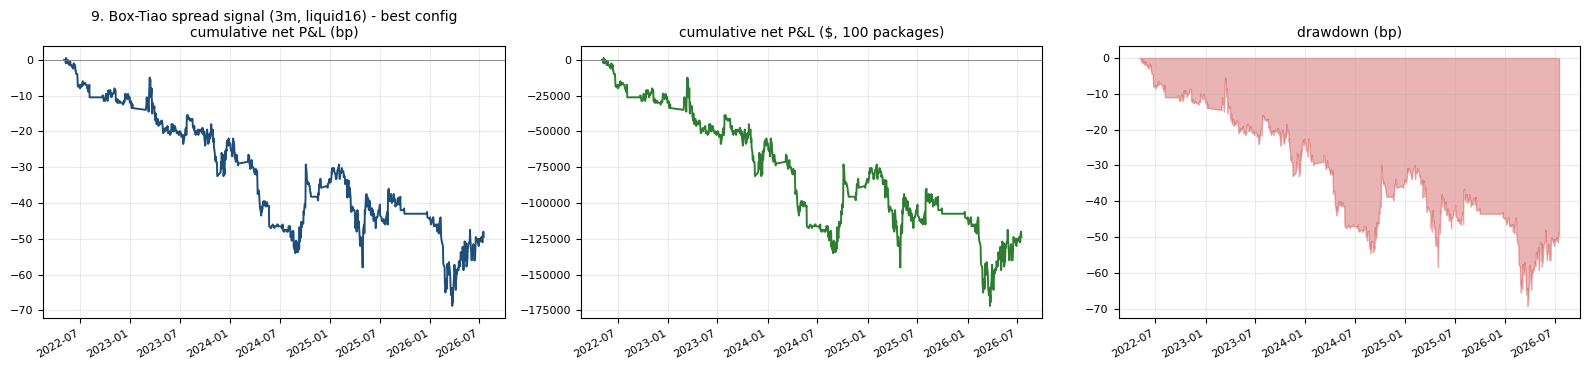


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
M25-U25-Z25   -1  2022-05-02 2022-05-03 2022-06-15    30  2.705      -2.5       -2.0      -0.5      1.5    -2.0  -5000.0       max_hold
H25-M25-U25    1  2022-05-06 2022-05-09 2022-06-22    30 -2.908      -1.0       -1.0       0.0      1.5    -1.5  -3750.0       max_hold
Z24-H25-M25    1  2022-05-09 2022-05-10 2022-06-23    30 -2.845      -0.5       -3.0      -2.5      1.5    -4.0 -10000.0       max_hold
H25-M25-U25    1  2022-06-27 2022-06-28 2022-08-05    27 -2.553      -2.0       -2.0      -0.0      1.5    -1.5  -3750.0 mean_reversion
Z24-H25-M25    1  2022-06-29 2022-06-30 2022-08-05    25 -2.553      -3.0       -3.0       0.0      1.5    -1.5  -3750.0 mean_reversion
U25-Z25-H26    1  2022-09-09 2022-09-12 2022-09-26    10 -2.635      -2.0       -1.5       0.5      1.5    -1.0  -2500.0 mean_reversion
M25-U25-Z25   -1  202


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       106           109.5         -49.5      -0.467     0.245  -0.572      -69.3      22.9          False             False
         belly       1            0.5       106            88.5          35.5       0.335     0.443   0.042     -342.0      22.9           True              True
belly_vs_front       2            1.0       106           -92.0        -198.0      -1.868     0.255  -1.376     -208.8      22.9          False             False
 belly_vs_back       2            1.0       106           201.5          95.5       0.901     0.491   0.826      -29.0      22.9           True              True
  -> SHADOWED - a simpler instrument beats the fly on net bp
9. Box-Tiao spread signal (3m, liquid16) - MEDIAN config

In [11]:
if not bt.empty:
    w_map = bt.set_index("key")[["w_front", "w_belly", "w_back"]]

    def bt_sig(L, z_window):
        out = {}
        for key, g in st.groupby("key"):
            if key not in w_map.index:
                continue
            g = g.sort_values("as_of")
            idx = pd.DatetimeIndex(g["as_of"])
            w = w_map.loc[key]
            s = (w["w_front"] * g["leg0_value"].to_numpy(float)
                 + w["w_belly"] * g["leg1_value"].to_numpy(float)
                 + w["w_back"] * g["leg2_value"].to_numpy(float)) * 100.0
            out[key] = pd.Series(s, index=idx)
        sp_df = pd.DataFrame(out).reindex(index=L.index, columns=L.columns)
        return zscore_signal(sp_df, window=z_window)

    out_bt = run_family(
        "9. Box-Tiao spread signal (3m, liquid16)", lab=lab, signal_fn=bt_sig,
        grid_spec={"z_window": (60, 120, 250), "entry_z": CONFIG["entry_zs"],
                   "exit_style": CONFIG["exits"],
                   "direction": CONFIG["directions"]},
        params=["z_window", "entry_z", "exit_style", "direction"],
        base=BASE, cls="arblab",
        note="most-mean-reverting weighting of the same three legs")
else:
    print("skipped: no Box-Tiao weights")